# Fama–French-style factor model for IMOEX constituents after 2022

This notebook estimates factor regressions for companies included in the **MOEX Russia Index (IMOEX)** as of **24 April 2026**.

The model is estimated on the post-2022 horizon:
$$
\text{Start date} = 2023\text{-}01\text{-}01
$$

The notebook uses:

1. **Ordinary price returns**
2. **Dividend-adjusted total returns**

The factor model is estimated in daily frequency first. Then daily alpha is annualized:

$$
\alpha_{annual} = (1+\alpha_{daily})^{252} - 1
$$

Regression specification:

$$
R_{i,t} - R_{f,t}
=
\alpha_i
+
\beta_{MKT,i}(R_{m,t}-R_{f,t})
+
\beta_{SMB,i}SMB_t
+
\beta_{HML,i}HML_t
+
\beta_{MOM,i}MOM_t
+
\varepsilon_{i,t}
$$

Important note: for the Russian market, a clean academic book-to-market factor is difficult to construct directly from MOEX ISS price data alone. Therefore, this notebook builds a practical **HML proxy** using trailing dividend yield. High-dividend-yield stocks are treated as “value”, while low-dividend-yield stocks are treated as “growth”.

In [1]:
# ============================================================
# 1. Imports and global settings
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from io import StringIO

import statsmodels.api as sm

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

AS_OF_DATE = "2026-04-24"

# Horizon after 2022:
# If you want to include 2022 itself, change this to "2022-01-01".
START_DATE = "2023-01-01"

TRADING_DAYS = 252
BATCH_SIZE = 100

INDEX_NAME = "IMOEX"
MARKET_PROXY = "MCFTR"

MIN_OBS = 300

print("Start date:", START_DATE)
print("End date:", AS_OF_DATE)

Start date: 2023-01-01
End date: 2026-04-24


## 1. MOEX ISS parser

This section uses the same MOEX ISS logic as before.  
The parser downloads JSON tables and handles pagination for historical data.

In [2]:
# ============================================================
# 2. Universal MOEX table parser
# ============================================================

def moex_get_table(url, table_name, params=None, timeout=30):
    """
    Universal parser for MOEX ISS JSON tables.
    """
    params = params or {}
    params.setdefault("iss.meta", "off")

    response = requests.get(url, params=params, timeout=timeout)
    response.raise_for_status()

    data = response.json()

    if table_name not in data:
        return pd.DataFrame()

    return pd.DataFrame(
        data[table_name]["data"],
        columns=data[table_name]["columns"]
    )


def get_stock_history(secid, start_date, end_date, board="TQBR"):
    """
    Downloads historical stock quotes from MOEX ISS.
    """
    url = (
        "https://iss.moex.com/iss/history/engines/stock/"
        f"markets/shares/boards/{board}/securities/{secid}.json"
    )

    rows = []
    start = 0

    while True:
        params = {
            "from": start_date,
            "till": end_date,
            "start": start,
            "iss.meta": "off"
        }

        df = moex_get_table(url, "history", params=params)

        if df.empty:
            break

        rows.append(df)

        if len(df) < BATCH_SIZE:
            break

        start += BATCH_SIZE

    if not rows:
        return pd.DataFrame()

    out = pd.concat(rows, ignore_index=True)
    out["TRADEDATE"] = pd.to_datetime(out["TRADEDATE"])
    out = out.sort_values("TRADEDATE")

    return out


def get_index_history(secid, start_date, end_date):
    """
    Downloads historical index quotes from MOEX ISS.
    """
    url = (
        "https://iss.moex.com/iss/history/engines/stock/"
        f"markets/index/securities/{secid}.json"
    )

    rows = []
    start = 0

    while True:
        params = {
            "from": start_date,
            "till": end_date,
            "start": start,
            "iss.meta": "off"
        }

        df = moex_get_table(url, "history", params=params)

        if df.empty:
            break

        rows.append(df)

        if len(df) < BATCH_SIZE:
            break

        start += BATCH_SIZE

    if not rows:
        return pd.DataFrame()

    out = pd.concat(rows, ignore_index=True)
    out["TRADEDATE"] = pd.to_datetime(out["TRADEDATE"])
    out = out.sort_values("TRADEDATE")

    return out

## 2. IMOEX constituents as of 24 April 2026

The list of securities is downloaded from the MOEX index analytics endpoint.  
The analysis is restricted to securities included in IMOEX on the selected date.

In [3]:
# ============================================================
# 3. IMOEX constituents
# ============================================================

def get_imoex_constituents(as_of_date):
    """
    Downloads IMOEX constituents from MOEX index analytics.
    """
    url = (
        "https://iss.moex.com/iss/statistics/engines/stock/"
        "markets/index/analytics/IMOEX.json"
    )

    df = moex_get_table(url, "analytics", params={"date": as_of_date})

    if df.empty:
        raise ValueError("IMOEX constituents were not loaded. Check the MOEX ISS endpoint.")

    ticker_col = None
    for col in df.columns:
        if "SECID" in col.upper():
            ticker_col = col
            break

    if ticker_col is None:
        print(df.columns.tolist())
        raise ValueError("Ticker column was not found in the IMOEX analytics table.")

    tickers = (
        df[ticker_col]
        .dropna()
        .astype(str)
        .str.upper()
        .unique()
        .tolist()
    )

    return tickers, df


imoex_tickers, imoex_constituents_table = get_imoex_constituents(AS_OF_DATE)

print("Number of IMOEX constituents:", len(imoex_tickers))
print(imoex_tickers)

imoex_constituents_table.head()

Number of IMOEX constituents: 20
['AFKS', 'AFLT', 'ALRS', 'BSPB', 'CBOM', 'CHMF', 'CNRU', 'DOMRF', 'ENPG', 'FLOT', 'GAZP', 'GMKN', 'HEAD', 'IRAO', 'LENT', 'LKOH', 'MAGN', 'MDMG', 'MOEX', 'MSNG']


,indexid,tradedate,ticker,shortnames,secids,weight,tradingsession,trade_session_date
0,IMOEX,2026-04-24,AFKS,Система ао,AFKS,0.32,3,2026-04-24
1,IMOEX,2026-04-24,AFLT,Аэрофлот,AFLT,0.54,3,2026-04-24
2,IMOEX,2026-04-24,ALRS,АЛРОСА ао,ALRS,0.42,3,2026-04-24
3,IMOEX,2026-04-24,BSPB,БСП ао,BSPB,0.35,3,2026-04-24
4,IMOEX,2026-04-24,CBOM,МКБ ао,CBOM,0.47,3,2026-04-24


## 3. Price returns and dividend-adjusted returns

Two return series are constructed for every stock.

### Price return

\[
r^{price}_{i,t} = \frac{P_{i,t}}{P_{i,t-1}} - 1
\]

### Dividend-adjusted total return

\[
r^{total}_{i,t} = \frac{P_{i,t} + D_{i,t}}{P_{i,t-1}} - 1
\]

Dividends are assigned to the first available trading day on or after the registry close date.  
This is a practical approximation because exact reinvestment dates may differ.

In [4]:
# ============================================================
# 4. Prices, dividends, and returns
# ============================================================

def select_price_column(df):
    """
    Selects the best available close-price column.
    """
    for col in ["LEGALCLOSEPRICE", "CLOSE", "WAPRICE", "MARKETPRICE2"]:
        if col in df.columns:
            return col

    raise ValueError("No suitable price column found.")


def get_price_series(ticker, start_date=START_DATE, end_date=AS_OF_DATE):
    """
    Downloads and returns a daily price series for a stock.
    """
    df = get_stock_history(ticker, start_date, end_date)

    if df.empty:
        return pd.Series(dtype=float, name=ticker)

    price_col = select_price_column(df)

    out = (
        df[["TRADEDATE", price_col]]
        .rename(columns={price_col: "price"})
        .dropna()
        .drop_duplicates("TRADEDATE")
        .set_index("TRADEDATE")
        .sort_index()
    )

    out["price"] = pd.to_numeric(out["price"], errors="coerce")
    out = out.dropna(subset=["price"])

    return out["price"].rename(ticker)


def get_dividends(ticker):
    """
    Downloads dividends from MOEX ISS.
    """
    url = f"https://iss.moex.com/iss/securities/{ticker}/dividends.json"

    try:
        df = moex_get_table(url, "dividends", params={"iss.meta": "off"})
    except Exception as e:
        print(f"Dividend loading error for {ticker}: {e}")
        return pd.DataFrame(columns=["date", "dividend"])

    if df.empty:
        return pd.DataFrame(columns=["date", "dividend"])

    date_col = None
    div_col = None

    for c in df.columns:
        cl = c.lower()
        if "registry" in cl and "date" in cl:
            date_col = c
            break

    if date_col is None:
        for c in df.columns:
            if "date" in c.lower():
                date_col = c
                break

    for c in df.columns:
        if "value" in c.lower() or "dividend" in c.lower():
            div_col = c
            break

    if date_col is None or div_col is None:
        print(f"Unexpected dividend columns for {ticker}: {df.columns.tolist()}")
        return pd.DataFrame(columns=["date", "dividend"])

    out = pd.DataFrame({
        "date": pd.to_datetime(df[date_col], errors="coerce"),
        "dividend": pd.to_numeric(df[div_col], errors="coerce")
    })

    out = out.dropna(subset=["date", "dividend"])
    out = out[(out["date"] >= pd.to_datetime(START_DATE)) & (out["date"] <= pd.to_datetime(AS_OF_DATE))]

    return out


def build_price_and_total_returns(ticker):
    """
    Builds both ordinary price return and dividend-adjusted total return.
    """
    price = get_price_series(ticker)

    if price.empty:
        return None

    df = price.to_frame("price")
    df["price_return"] = df["price"].pct_change()

    df["dividend"] = 0.0
    dividends = get_dividends(ticker)

    for _, row in dividends.iterrows():
        possible_dates = df.index[df.index >= row["date"]]
        if len(possible_dates) > 0:
            dividend_date = possible_dates[0]
            df.loc[dividend_date, "dividend"] += row["dividend"]

    df["total_return"] = (df["price"] + df["dividend"]) / df["price"].shift(1) - 1

    return df[["price_return", "total_return", "price", "dividend"]].dropna()

## 4. Load all returns and keep only complete observations

The notebook keeps only stocks for which **all observations are present** over the aligned post-2022 trading calendar.

The cleaning logic is:

1. Build return matrices for all IMOEX securities.
2. Align all stocks on the same trading calendar.
3. Drop any security with at least one missing observation in either price returns or total returns.
4. Keep only securities with a sufficient number of observations.

In [5]:
# ============================================================
# 5. Load returns for all IMOEX constituents
# ============================================================

price_returns = {}
total_returns = {}
prices = {}
dividends_cash = {}

failed_tickers = []

for ticker in imoex_tickers:
    try:
        data = build_price_and_total_returns(ticker)

        if data is None or data.empty:
            failed_tickers.append((ticker, "empty data"))
            continue

        price_returns[ticker] = data["price_return"]
        total_returns[ticker] = data["total_return"]
        prices[ticker] = data["price"]
        dividends_cash[ticker] = data["dividend"]

    except Exception as e:
        failed_tickers.append((ticker, str(e)))

R_price_raw = pd.DataFrame(price_returns).sort_index()
R_total_raw = pd.DataFrame(total_returns).sort_index()
P_raw = pd.DataFrame(prices).sort_index()
D_raw = pd.DataFrame(dividends_cash).sort_index()

print("Raw price-return matrix:", R_price_raw.shape)
print("Raw total-return matrix:", R_total_raw.shape)
print("Failed tickers:", failed_tickers[:20])

Raw price-return matrix: (841, 20)
Raw total-return matrix: (841, 20)
Failed tickers: []


In [6]:
# ============================================================
# 6. Keep only stocks with complete observations
# ============================================================

common_index = R_price_raw.index.intersection(R_total_raw.index)

R_price_aligned = R_price_raw.reindex(common_index)
R_total_aligned = R_total_raw.reindex(common_index)
P_aligned = P_raw.reindex(common_index)
D_aligned = D_raw.reindex(common_index).fillna(0.0)

candidate_tickers = R_price_aligned.columns.intersection(R_total_aligned.columns)

complete_tickers = []

for ticker in candidate_tickers:
    has_complete_price = R_price_aligned[ticker].notna().all()
    has_complete_total = R_total_aligned[ticker].notna().all()
    has_enough_obs = R_price_aligned[ticker].notna().sum() >= MIN_OBS

    if has_complete_price and has_complete_total and has_enough_obs:
        complete_tickers.append(ticker)

R_price = R_price_aligned[complete_tickers].copy()
R_total = R_total_aligned[complete_tickers].copy()
P = P_aligned[complete_tickers].copy()
D = D_aligned[complete_tickers].copy()

print("Initial number of IMOEX tickers:", len(imoex_tickers))
print("Tickers with complete observations:", len(complete_tickers))
print(complete_tickers)

display(pd.DataFrame({
    "ticker": complete_tickers,
    "observations": [R_total[t].notna().sum() for t in complete_tickers]
}).head(100))

Initial number of IMOEX tickers: 20
Tickers with complete observations: 17
['AFKS', 'AFLT', 'ALRS', 'BSPB', 'CBOM', 'CHMF', 'ENPG', 'FLOT', 'GAZP', 'GMKN', 'IRAO', 'LENT', 'LKOH', 'MAGN', 'MDMG', 'MOEX', 'MSNG']


,ticker,observations
0,AFKS,841
1,AFLT,841
2,ALRS,841
3,BSPB,841
4,CBOM,841
5,CHMF,841
6,ENPG,841
7,FLOT,841
8,GAZP,841
9,GMKN,841


## 5. Market return and risk-free rate

The market factor is built using the MOEX total return index proxy.

\[
MKT_t = R_{m,t} - R_{f,t}
\]

The risk-free rate is the **10-year CBR zero-coupon yield** on the analysis date.  
The annual rate is converted into daily frequency:

\[
R_{f,daily} = (1 + R_{f,annual})^{1/252} - 1
\]

In [7]:
# ============================================================
# 7. Market return
# ============================================================

def get_market_return(secid=MARKET_PROXY, start_date=START_DATE, end_date=AS_OF_DATE):
    """
    Downloads and computes daily market return from a MOEX index.
    """
    df = get_index_history(secid, start_date, end_date)

    if df.empty:
        raise ValueError(f"Market index data is empty for {secid}")

    price_col = select_price_column(df)

    market = (
        df[["TRADEDATE", price_col]]
        .rename(columns={price_col: "market"})
        .dropna()
        .drop_duplicates("TRADEDATE")
        .set_index("TRADEDATE")
        .sort_index()
    )

    market["market"] = pd.to_numeric(market["market"], errors="coerce")
    market = market.dropna(subset=["market"])

    return market["market"].pct_change().dropna().rename("market_return")


market_return = get_market_return()

common_index = R_total.index.intersection(market_return.index)

R_price = R_price.reindex(common_index)
R_total = R_total.reindex(common_index)
P = P.reindex(common_index)
D = D.reindex(common_index).fillna(0.0)
market_return = market_return.reindex(common_index)

complete_tickers = [
    t for t in complete_tickers
    if R_price[t].notna().all() and R_total[t].notna().all()
]

R_price = R_price[complete_tickers]
R_total = R_total[complete_tickers]
P = P[complete_tickers]
D = D[complete_tickers]

print("Final clean price-return matrix:", R_price.shape)
print("Final clean total-return matrix:", R_total.shape)
print("Market return observations:", market_return.shape)
print("Final tickers:", complete_tickers)

Final clean price-return matrix: (840, 17)
Final clean total-return matrix: (840, 17)
Market return observations: (840,)
Final tickers: ['AFKS', 'AFLT', 'ALRS', 'BSPB', 'CBOM', 'CHMF', 'ENPG', 'FLOT', 'GAZP', 'GMKN', 'IRAO', 'LENT', 'LKOH', 'MAGN', 'MDMG', 'MOEX', 'MSNG']


In [8]:

# ============================================================
# Cell 7. CBR 10-year zero-coupon risk-free rate
# ============================================================

import re
import numpy as np
import pandas as pd
import requests
from bs4 import BeautifulSoup
from datetime import datetime

def get_cbr_10y_zero_coupon_rate(as_of_date, fallback_10y_rate_pct=None):
    """
    Parse CBR zero-coupon yield curve and return the interpolated 10Y rate.

    Parameters
    ----------
    as_of_date : str or datetime-like
        Target date.
    fallback_10y_rate_pct : float or None
        Optional fallback value in percent, e.g. 14.26.
        If parsing fails and fallback is provided, the function returns it.

    Returns
    -------
    rf_10y_decimal : float
        10Y zero-coupon rate in decimal form.
    zcyc : pd.DataFrame
        Parsed yield curve table with maturity and yield columns.
    """

    url = "https://www.cbr.ru/hd_base/zcyc_params/zcyc/"
    date_rus = pd.to_datetime(as_of_date).strftime("%d.%m.%Y")

    params = {
        "DateTo": date_rus
    }

    headers = {
        "User-Agent": "Mozilla/5.0",
        "Accept-Language": "ru-RU,ru;q=0.9,en;q=0.8",
    }

    try:
        response = requests.get(
            url,
            params=params,
            headers=headers,
            timeout=30
        )
        response.raise_for_status()

        soup = BeautifulSoup(response.text, "html.parser")
        text = soup.get_text("\n", strip=True).replace("\xa0", " ")

        lines = [
            re.sub(r"\s+", " ", line).strip()
            for line in text.splitlines()
        ]
        lines = [line for line in lines if line]

        maturity_idx = next(
            (i for i, line in enumerate(lines) if "Срок до погашения" in line),
            None
        )

        yield_idx = next(
            (i for i, line in enumerate(lines) if "Доходность" in line and "% годовых" in line),
            None
        )

        if maturity_idx is None or yield_idx is None:
            raise ValueError(
                "Could not find maturity/yield headings on the CBR page."
            )

        def collect_numbers_after(start_idx, stop_idx=None, max_count=12):
            nums = []
            end = stop_idx if stop_idx is not None else len(lines)

            for j in range(start_idx + 1, end):
                found = re.findall(r"\d+(?:[.,]\d+)?", lines[j])
                for x in found:
                    nums.append(float(x.replace(",", ".")))
                    if len(nums) >= max_count:
                        return nums
            return nums

        maturities = collect_numbers_after(
            maturity_idx,
            stop_idx=yield_idx,
            max_count=12
        )

        yields = collect_numbers_after(
            yield_idx,
            stop_idx=None,
            max_count=12
        )

        if len(maturities) != len(yields) or len(maturities) == 0:
            raise ValueError(
                f"Failed to parse CBR curve. "
                f"maturities={maturities}, yields={yields}"
            )

        zcyc = pd.DataFrame({
            "maturity": maturities,
            "yield": yields
        }).sort_values("maturity")

        rf_10y_percent = np.interp(
            10.0,
            zcyc["maturity"],
            zcyc["yield"]
        )

        return rf_10y_percent / 100, zcyc

    except Exception as e:
        if fallback_10y_rate_pct is None:
            raise ValueError(f"CBR ZCYC parsing failed: {e}") from e

        zcyc = pd.DataFrame({
            "maturity": [10.0],
            "yield": [fallback_10y_rate_pct]
        })

        return fallback_10y_rate_pct / 100, zcyc


rf_annual, zcyc_table = get_cbr_10y_zero_coupon_rate(
    AS_OF_DATE,
    fallback_10y_rate_pct=14.26
)

rf_daily = (1 + rf_annual) ** (1 / TRADING_DAYS) - 1

print(f"10Y risk-free rate on {AS_OF_DATE}: {rf_annual:.4%}")
print(f"Daily risk-free rate: {rf_daily:.6%}")
display(zcyc_table)


10Y risk-free rate on 2026-04-24: 14.5200%
Daily risk-free rate: 0.053816%


,maturity,yield
0,0.25,12.64
1,0.50,12.82
2,0.75,12.98
3,1.00,13.11
4,2.00,13.52
5,3.00,13.82
6,5.00,14.25
7,7.00,14.46
8,10.00,14.52
9,15.00,14.44


## 6. Construct SMB, HML, and MOM factors

The factors are constructed from the same clean universe of IMOEX stocks.

### SMB: Small Minus Big

$$
SMB_t = R_{Small,t} - R_{Big,t}
$$

### HML: High Minus Low

The HML factor is a value proxy based on trailing dividend yield:

$$
Value\ proxy = \frac{\sum Dividends}{Latest\ Price}
$$

$$
HML_t = R_{High\ value,t} - R_{Low\ value,t}
$$

### MOM: Momentum

$$
MOM_t = R_{Winners,t} - R_{Losers,t}
$$

In [9]:
# ============================================================
# 9. Size and value classification
# ============================================================

def get_moex_share_snapshot():
    """
    Downloads current MOEX TQBR snapshot with issue size and prices.
    Used for an approximate market-cap proxy.
    """
    url = "https://iss.moex.com/iss/engines/stock/markets/shares/boards/TQBR/securities.json"

    params = {
        "iss.meta": "off",
        "securities.columns": "SECID,SHORTNAME,LOTSIZE,ISSUESIZE,PREVPRICE"
    }

    return moex_get_table(url, "securities", params=params)


snapshot = get_moex_share_snapshot()

snapshot["SECID"] = snapshot["SECID"].astype(str).str.upper()
snapshot = snapshot[snapshot["SECID"].isin(complete_tickers)].copy()

for col in ["ISSUESIZE", "PREVPRICE", "LOTSIZE"]:
    if col in snapshot.columns:
        snapshot[col] = pd.to_numeric(snapshot[col], errors="coerce")

snapshot["market_cap_proxy"] = snapshot["ISSUESIZE"] * snapshot["PREVPRICE"]

latest_prices = P.ffill().iloc[-1]

snapshot = snapshot.set_index("SECID")

size_score = snapshot["market_cap_proxy"].reindex(complete_tickers)
size_score = size_score.fillna(latest_prices)

dividend_sum = D[complete_tickers].sum()
value_score = dividend_sum / latest_prices
value_score = value_score.replace([np.inf, -np.inf], np.nan).fillna(0.0)

classification = pd.DataFrame({
    "size_score": size_score,
    "value_score_dividend_yield": value_score,
    "latest_price": latest_prices,
    "dividend_sum_period": dividend_sum
})

classification.head(30)

,size_score,value_score_dividend_yield,latest_price,dividend_sum_period
AFKS,1.191775e+11,0.075647,12.294,0.930000
AFLT,1.962043e+11,0.106379,49.540,5.270000
ALRS,2.294923e+11,0.264621,31.290,8.280000
BSPB,1.515990e+11,0.354291,340.370,120.590000
CBOM,2.237785e+11,0.000000,6.642,0.000000
CHMF,6.891074e+11,0.329408,824.600,271.630000
ENPG,2.901971e+11,0.000000,455.200,0.000000
FLOT,1.981220e+11,0.262760,83.270,21.880000
GAZP,2.963214e+12,0.000000,125.180,0.000000
GMKN,2.133973e+12,6.500923,140.800,915.330000


In [10]:
# ============================================================
# 10. Factor construction
# ============================================================

def get_tercile_groups(score_series):
    """
    Splits securities into low/mid/high terciles.
    Uses rank to handle duplicated values.
    """
    ranked = score_series.rank(method="first")
    return pd.qcut(ranked, 3, labels=["low", "mid", "high"])


size_group = get_tercile_groups(size_score)
value_group = get_tercile_groups(value_score)

small = size_group[size_group == "low"].index.tolist()
big = size_group[size_group == "high"].index.tolist()

high_value = value_group[value_group == "high"].index.tolist()
low_value = value_group[value_group == "low"].index.tolist()

mom_score = (1 + R_total).prod() - 1
mom_group = get_tercile_groups(mom_score)

winners = mom_group[mom_group == "high"].index.tolist()
losers = mom_group[mom_group == "low"].index.tolist()

factor_groups = {
    "Small": small,
    "Big": big,
    "High value": high_value,
    "Low value": low_value,
    "Momentum winners": winners,
    "Momentum losers": losers
}

for name, group in factor_groups.items():
    print(name, ":", group)

SMB = R_total[small].mean(axis=1) - R_total[big].mean(axis=1)
HML = R_total[high_value].mean(axis=1) - R_total[low_value].mean(axis=1)
MOM = R_total[winners].mean(axis=1) - R_total[losers].mean(axis=1)

factors = pd.DataFrame({
    "MKT": market_return - rf_daily,
    "SMB": SMB,
    "HML": HML,
    "MOM": MOM
}).dropna()

factors.head()

Small : ['AFKS', 'AFLT', 'BSPB', 'FLOT', 'MDMG', 'MSNG']
Big : ['CHMF', 'GAZP', 'GMKN', 'IRAO', 'LKOH', 'MOEX']
High value : ['BSPB', 'CHMF', 'GMKN', 'IRAO', 'LKOH', 'MOEX']
Low value : ['AFKS', 'AFLT', 'CBOM', 'ENPG', 'GAZP', 'LENT']
Momentum winners : ['AFLT', 'BSPB', 'FLOT', 'LENT', 'MDMG', 'MOEX']
Momentum losers : ['AFKS', 'ALRS', 'CBOM', 'GAZP', 'GMKN', 'MAGN']


,MKT,SMB,HML,MOM
TRADEDATE,,,,
2023-01-04,-0.002500,0.008530,-0.005348,0.003199
2023-01-05,-0.005956,0.008927,0.000609,0.014046
2023-01-06,-0.000668,-0.004064,0.003456,-0.003779
2023-01-09,0.003312,-0.001334,-0.003249,0.007070
2023-01-10,-0.002382,0.006262,-0.018107,0.002219


## 7. Fama–French-style regressions

The model is estimated separately for:

1. Ordinary price returns
2. Dividend-adjusted total returns

The dependent variable is excess stock return:

$$
R_{i,t} - R_{f,t}
$$

The regressors are:

- Market excess return
- SMB
- HML
- MOM

The model is estimated in daily frequency. Then alpha is annualized:

$$
\alpha_{annual} = (1+\alpha_{daily})^{252} - 1
$$

In [12]:
# ============================================================
# 12. Regression function
# ============================================================

def fama_french_regression(return_matrix, factors, rf_daily):
    """
    Runs daily Fama-French-style regressions for all stocks.

    Returns:
    - result table with coefficients, t-stats, p-values, R2
    - fitted model objects
    """
    results = []
    models = {}

    common_index = return_matrix.index.intersection(factors.index)

    R = return_matrix.reindex(common_index)
    F = factors.reindex(common_index)

    for ticker in R.columns:
        df = pd.concat(
            [
                R[ticker].rename("asset_return"),
                F[["MKT", "SMB", "HML", "MOM"]]
            ],
            axis=1
        ).dropna()

        if len(df) < MIN_OBS:
            continue

        y = df["asset_return"] - rf_daily
        X = sm.add_constant(df[["MKT", "SMB", "HML", "MOM"]])

        model = sm.OLS(y, X).fit()

        alpha_daily = model.params["const"]
        alpha_annual = (1 + alpha_daily) ** TRADING_DAYS - 1

        row = {
            "ticker": ticker,

            "alpha_daily": alpha_daily,
            "alpha_annual": alpha_annual,

            "MKT": model.params.get("MKT", np.nan),
            "SMB": model.params.get("SMB", np.nan),
            "HML": model.params.get("HML", np.nan),
            "MOM": model.params.get("MOM", np.nan),

            "R2": model.rsquared,
            "adj_R2": model.rsquared_adj,
            "observations": int(model.nobs),

            "t_alpha": model.tvalues.get("const", np.nan),
            "t_MKT": model.tvalues.get("MKT", np.nan),
            "t_SMB": model.tvalues.get("SMB", np.nan),
            "t_HML": model.tvalues.get("HML", np.nan),
            "t_MOM": model.tvalues.get("MOM", np.nan),

            "p_alpha": model.pvalues.get("const", np.nan),
            "p_MKT": model.pvalues.get("MKT", np.nan),
            "p_SMB": model.pvalues.get("SMB", np.nan),
            "p_HML": model.pvalues.get("HML", np.nan),
            "p_MOM": model.pvalues.get("MOM", np.nan),
        }

        results.append(row)
        models[ticker] = model

    result_df = pd.DataFrame(results)

    if not result_df.empty:
        result_df = result_df.set_index("ticker").sort_values("R2", ascending=False)

    return result_df, models


ff_price, models_price = fama_french_regression(R_price, factors, rf_daily)
ff_total, models_total = fama_french_regression(R_total, factors, rf_daily)

print("Price-return regressions:", ff_price.shape)
print("Total-return regressions:", ff_total.shape)

display(ff_total.head())

Price-return regressions: (17, 19)
Total-return regressions: (17, 19)


,alpha_daily,alpha_annual,MKT,SMB,HML,MOM,R2,adj_R2,observations,t_alpha,t_MKT,t_SMB,t_HML,t_MOM,p_alpha,p_MKT,p_SMB,p_HML,p_MOM
ticker,,,,,,,,,,,,,,,,,,,
GAZP,-0.000371,-0.089375,1.129720,-0.411065,-0.333824,-0.019710,0.718193,0.716843,840,-1.098893,38.193319,-8.660185,-9.470263,-0.489127,0.272131,2.073382e-185,2.409483e-17,2.782364e-20,6.248804e-01
AFKS,-0.000172,-0.042479,1.199871,0.784165,-0.102414,-0.574377,0.703093,0.701670,840,-0.411758,32.780728,13.350330,-2.347866,-11.518569,0.680623,3.787315e-152,5.453698e-37,1.911383e-02,1.351451e-28
GMKN,0.000871,0.245361,1.108650,-0.226631,1.825136,-1.431319,0.682420,0.680899,840,1.152569,16.762973,-2.135380,23.156893,-15.885828,0.249417,1.392080e-54,3.302036e-02,5.047131e-92,7.494640e-50
CHMF,-0.000308,-0.074747,1.183064,-0.000133,0.178669,-0.044229,0.585592,0.583607,840,-0.734712,32.225799,-0.002251,4.083891,-0.884334,0.462721,1.095609e-148,9.982048e-01,4.854969e-05,3.767708e-01
LKOH,0.000048,0.012209,0.968723,-0.237323,0.092074,0.243028,0.575081,0.573046,840,0.143539,32.997514,-5.037571,2.631753,6.076528,0.885899,1.690926e-153,5.780194e-07,8.651306e-03,1.865324e-09


## 8. Regression tables with statistical significance

Stars are assigned as follows:

- `***` if p-value < 1%
- `**` if p-value < 5%
- `*` if p-value < 10%

The table reports coefficients with t-statistics in parentheses.

In [13]:
# ============================================================
# 13. Pretty regression tables
# ============================================================

def significance_stars(p):
    if pd.isna(p):
        return ""
    if p < 0.01:
        return "***"
    if p < 0.05:
        return "**"
    if p < 0.10:
        return "*"
    return ""


def significance_stars_vector(p_values):
    return p_values.apply(significance_stars)


def make_regression_table(ff):
    """
    Creates a compact academic-style table.
    """
    if ff.empty:
        return pd.DataFrame()

    table = pd.DataFrame(index=ff.index)

    table["alpha_daily"] = (
        ff["alpha_daily"].round(5).astype(str)
        + significance_stars_vector(ff["p_alpha"])
        + " ("
        + ff["t_alpha"].round(2).astype(str)
        + ")"
    )

    table["alpha_annual"] = ff["alpha_annual"].round(4)

    for factor in ["MKT", "SMB", "HML", "MOM"]:
        table[factor] = (
            ff[factor].round(4).astype(str)
            + significance_stars_vector(ff[f"p_{factor}"])
            + " ("
            + ff[f"t_{factor}"].round(2).astype(str)
            + ")"
        )

    table["R2"] = ff["R2"].round(4)
    table["adj_R2"] = ff["adj_R2"].round(4)
    table["observations"] = ff["observations"].astype(int)

    return table



ff_price_table = make_regression_table(ff_price)
ff_total_table = make_regression_table(ff_total)

print("Dividend-adjusted total-return regression table:")
display(ff_total_table.head(30))

print("Ordinary price-return regression table:")
display(ff_price_table.head(30))

Dividend-adjusted total-return regression table:


,alpha_daily,alpha_annual,MKT,SMB,HML,MOM,R2,adj_R2,observations
ticker,,,,,,,,,
GAZP,-0.00037 (-1.1),-0.0894,1.1297*** (38.19),-0.4111*** (-8.66),-0.3338*** (-9.47),-0.0197 (-0.49),0.7182,0.7168,840
AFKS,-0.00017 (-0.41),-0.0425,1.1999*** (32.78),0.7842*** (13.35),-0.1024** (-2.35),-0.5744*** (-11.52),0.7031,0.7017,840
GMKN,0.00087 (1.15),0.2454,1.1087*** (16.76),-0.2266** (-2.14),1.8251*** (23.16),-1.4313*** (-15.89),0.6824,0.6809,840
CHMF,-0.00031 (-0.73),-0.0747,1.1831*** (32.23),-0.0001 (-0.0),0.1787*** (4.08),-0.0442 (-0.88),0.5856,0.5836,840
LKOH,5e-05 (0.14),0.0122,0.9687*** (33.0),-0.2373*** (-5.04),0.0921*** (2.63),0.243*** (6.08),0.5751,0.5730,840
ALRS,-0.00078** (-2.01),-0.1791,0.9489*** (27.81),0.3025*** (5.53),0.0924** (2.27),-0.3751*** (-8.07),0.5744,0.5724,840
MAGN,-0.00037 (-0.87),-0.0901,1.0721*** (28.32),0.3591*** (5.91),0.184*** (4.08),-0.346*** (-6.71),0.5641,0.5620,840
BSPB,0.00022 (0.41),0.0559,0.9937*** (21.48),1.3742*** (18.51),1.1139*** (20.21),-0.052 (-0.83),0.5530,0.5509,840
AFLT,-7e-05 (-0.15),-0.0177,1.1669*** (28.12),0.1551** (2.33),-0.1877*** (-3.79),0.2196*** (3.88),0.5510,0.5488,840


Ordinary price-return regression table:


,alpha_daily,alpha_annual,MKT,SMB,HML,MOM,R2,adj_R2,observations
ticker,,,,,,,,,
GAZP,-0.00037 (-1.1),-0.0894,1.1297*** (38.19),-0.4111*** (-8.66),-0.3338*** (-9.47),-0.0197 (-0.49),0.7182,0.7168,840
AFKS,-0.00023 (-0.55),-0.0565,1.2012*** (32.71),0.7851*** (13.32),-0.0991** (-2.26),-0.5734*** (-11.46),0.7016,0.7002,840
GMKN,0.0008 (1.05),0.2221,1.108*** (16.64),-0.2158** (-2.02),1.8266*** (23.02),-1.4312*** (-15.78),0.6785,0.6770,840
ALRS,-0.00094** (-2.42),-0.2120,0.951*** (27.79),0.3138*** (5.72),0.0917** (2.25),-0.3726*** (-7.99),0.5737,0.5716,840
LKOH,-0.00038 (-1.13),-0.0913,0.9465*** (32.29),-0.2307*** (-4.9),0.0508 (1.45),0.2349*** (5.88),0.5668,0.5647,840
MAGN,-0.00051 (-1.17),-0.1212,1.0837*** (28.26),0.3689*** (5.99),0.1929*** (4.22),-0.3452*** (-6.61),0.5620,0.5599,840
CHMF,-0.00054 (-1.21),-0.1283,1.211*** (30.65),-0.0318 (-0.5),0.1752*** (3.72),-0.0103 (-0.19),0.5580,0.5559,840
ENPG,-0.00024 (-0.45),-0.0586,1.1812*** (25.38),-0.1536** (-2.06),-0.5679*** (-10.24),0.1173* (1.85),0.5497,0.5475,840
AFLT,-0.00018 (-0.38),-0.0441,1.1493*** (27.52),0.1614** (2.41),-0.1856*** (-3.73),0.2208*** (3.88),0.5413,0.5391,840


In [14]:
# ============================================================
# 14. Separate coefficient, t-stat, and p-value tables
# ============================================================

coef_cols = ["MKT", "SMB", "HML", "MOM", "alpha_daily", "alpha_annual", "R2", "adj_R2", "observations"]
t_cols = ["t_alpha", "t_MKT", "t_SMB", "t_HML", "t_MOM"]
p_cols = ["p_alpha", "p_MKT", "p_SMB", "p_HML", "p_MOM"]

# Robust against missing columns.
coef_cols_total = [c for c in coef_cols if c in ff_total.columns]
coef_cols_price = [c for c in coef_cols if c in ff_price.columns]

ff_total_coef = ff_total[coef_cols_total].round(4)
ff_price_coef = ff_price[coef_cols_price].round(4)

ff_total_t = ff_total[[c for c in t_cols if c in ff_total.columns]].round(3)
ff_total_p = ff_total[[c for c in p_cols if c in ff_total.columns]].round(4)

print("Total-return coefficients:")
display(ff_total_coef.head(30))

print("Total-return t-statistics:")
display(ff_total_t.head(30))

print("Total-return p-values:")
display(ff_total_p.head(30))

Total-return coefficients:


,MKT,SMB,HML,MOM,alpha_daily,alpha_annual,R2,adj_R2,observations
ticker,,,,,,,,,
GAZP,1.1297,-0.4111,-0.3338,-0.0197,-0.0004,-0.0894,0.7182,0.7168,840
AFKS,1.1999,0.7842,-0.1024,-0.5744,-0.0002,-0.0425,0.7031,0.7017,840
GMKN,1.1087,-0.2266,1.8251,-1.4313,0.0009,0.2454,0.6824,0.6809,840
CHMF,1.1831,-0.0001,0.1787,-0.0442,-0.0003,-0.0747,0.5856,0.5836,840
LKOH,0.9687,-0.2373,0.0921,0.2430,0.0000,0.0122,0.5751,0.5730,840
ALRS,0.9489,0.3025,0.0924,-0.3751,-0.0008,-0.1791,0.5744,0.5724,840
MAGN,1.0721,0.3591,0.1840,-0.3460,-0.0004,-0.0901,0.5641,0.5620,840
BSPB,0.9937,1.3742,1.1139,-0.0520,0.0002,0.0559,0.5530,0.5509,840
AFLT,1.1669,0.1551,-0.1877,0.2196,-0.0001,-0.0177,0.5510,0.5488,840


Total-return t-statistics:


,t_alpha,t_MKT,t_SMB,t_HML,t_MOM
ticker,,,,,
GAZP,-1.099,38.193,-8.660,-9.470,-0.489
AFKS,-0.412,32.781,13.350,-2.348,-11.519
GMKN,1.153,16.763,-2.135,23.157,-15.886
CHMF,-0.735,32.226,-0.002,4.084,-0.884
LKOH,0.144,32.998,-5.038,2.632,6.077
ALRS,-2.008,27.811,5.526,2.273,-8.070
MAGN,-0.866,28.315,5.910,4.077,-6.708
BSPB,0.409,21.481,18.511,20.205,-0.825
AFLT,-0.150,28.120,2.329,-3.795,3.884


Total-return p-values:


,p_alpha,p_MKT,p_SMB,p_HML,p_MOM
ticker,,,,,
GAZP,0.2721,0.0,0.0000,0.0000,0.6249
AFKS,0.6806,0.0,0.0000,0.0191,0.0000
GMKN,0.2494,0.0,0.0330,0.0000,0.0000
CHMF,0.4627,0.0,0.9982,0.0000,0.3768
LKOH,0.8859,0.0,0.0000,0.0087,0.0000
ALRS,0.0450,0.0,0.0000,0.0233,0.0000
MAGN,0.3867,0.0,0.0000,0.0000,0.0000
BSPB,0.6829,0.0,0.0000,0.0000,0.4094
AFLT,0.8810,0.0,0.0201,0.0002,0.0001


## 9. Visual analysis

The charts below show:

1. Ranked market beta
2. Ranked SMB beta
3. Ranked HML beta
4. Ranked MOM beta
5. Annualized alpha
6. \(R^2\) comparison between ordinary price returns and dividend-adjusted total returns

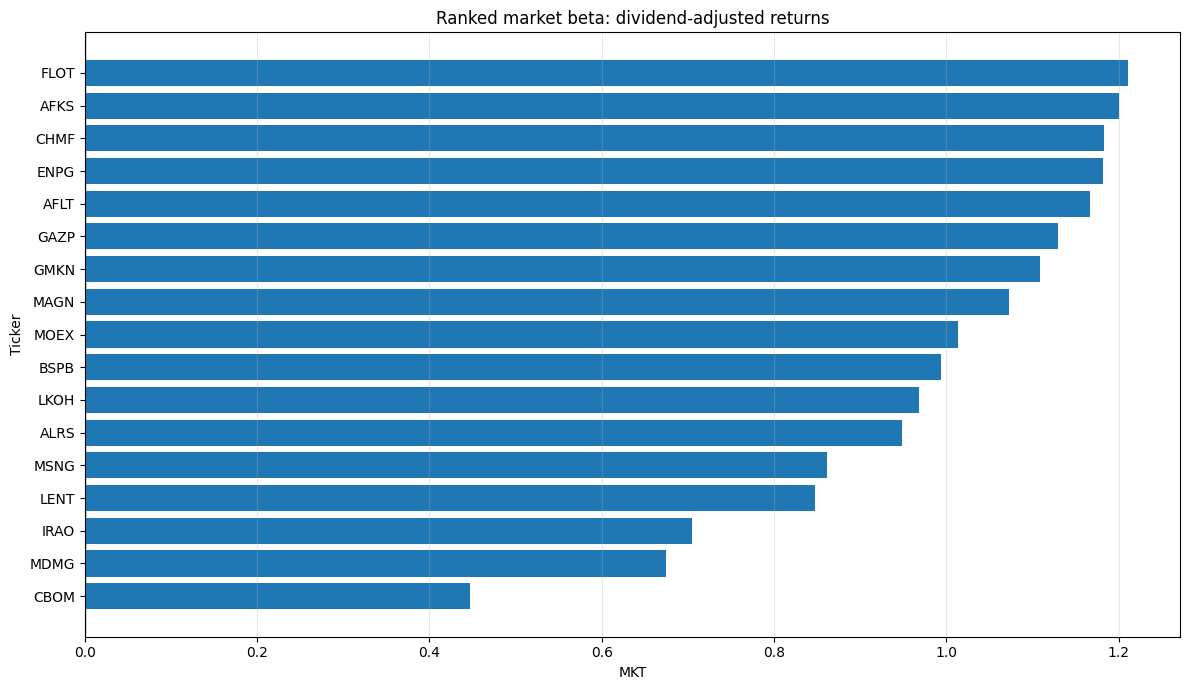

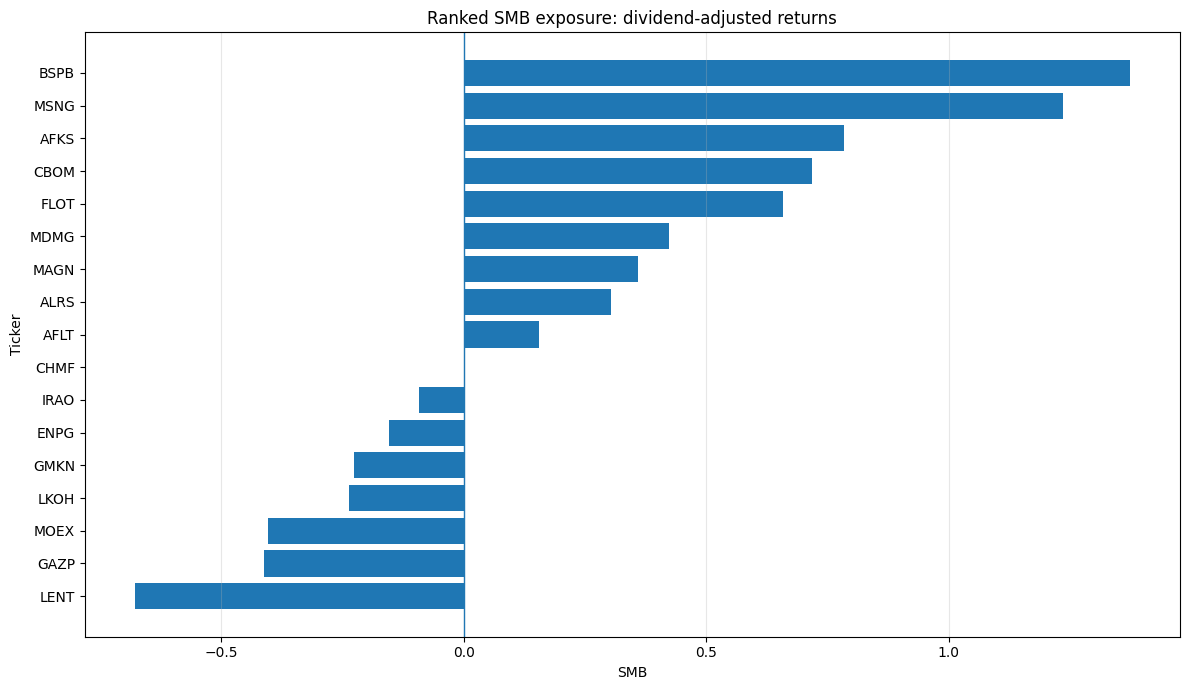

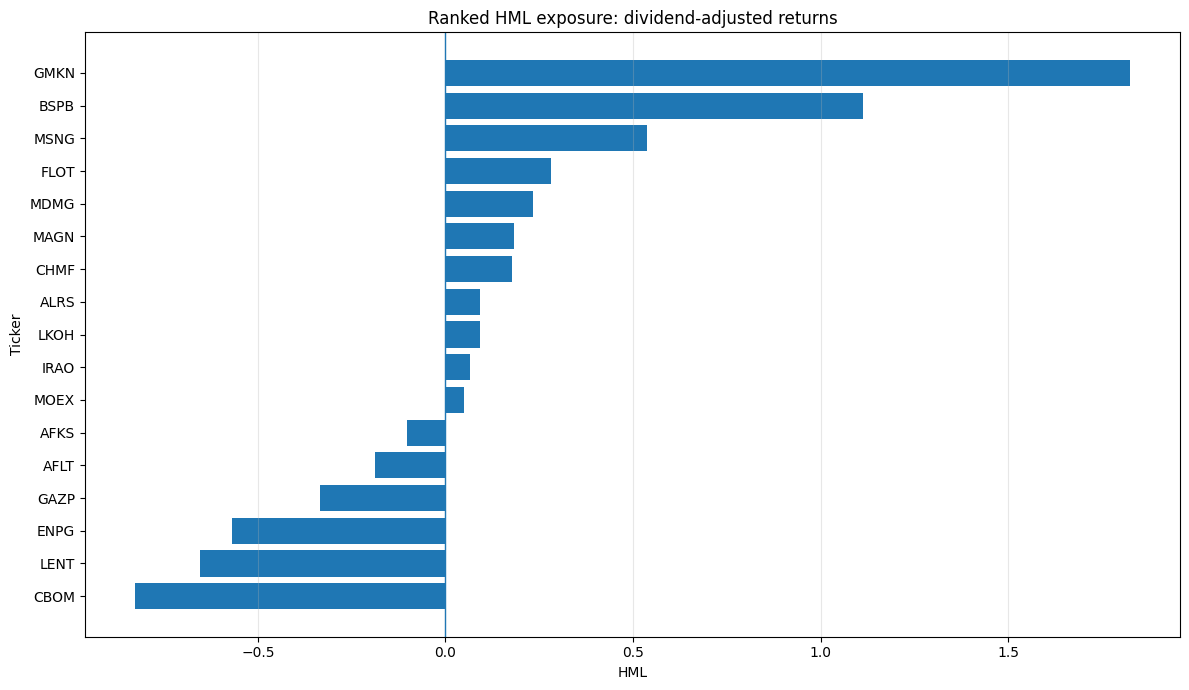

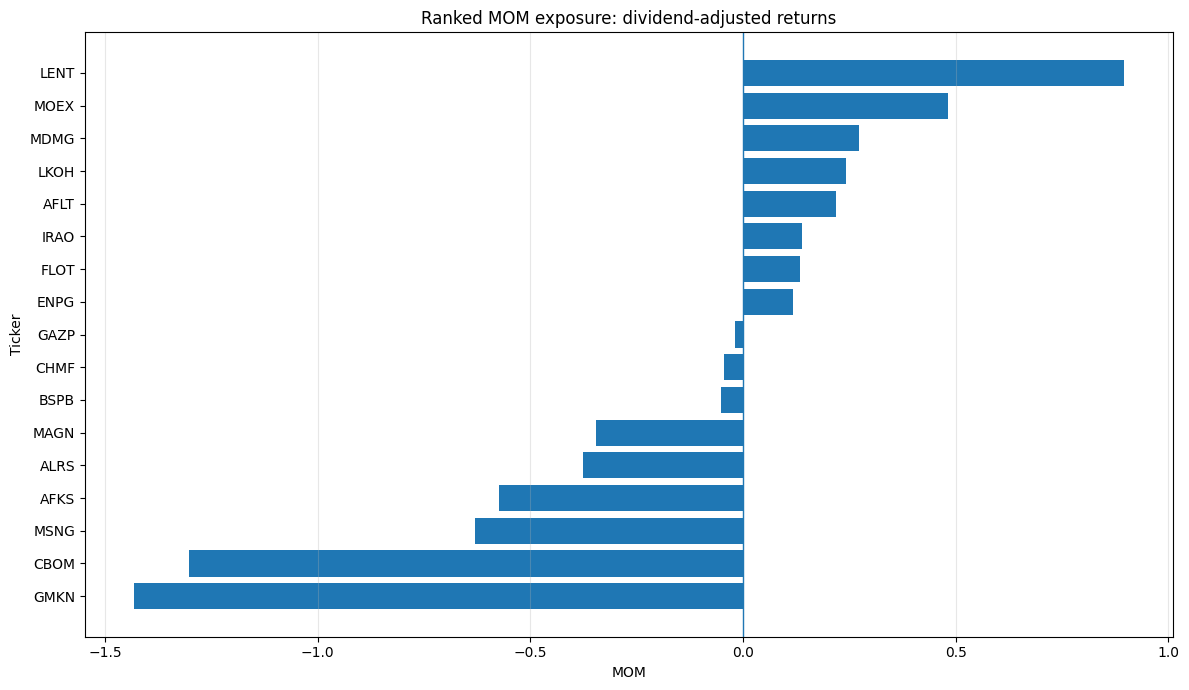

In [15]:
# ============================================================
# 15. Ranked factor exposures
# ============================================================

def plot_ranked_exposure(ff, column, title):
    if ff.empty or column not in ff.columns:
        print(f"Column {column} is unavailable.")
        return

    s = ff[column].sort_values()

    plt.figure(figsize=(12, 7))
    plt.barh(s.index, s.values)
    plt.axvline(0, linewidth=1)
    plt.title(title)
    plt.xlabel(column)
    plt.ylabel("Ticker")
    plt.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_ranked_exposure(ff_total, "MKT", "Ranked market beta: dividend-adjusted returns")
plot_ranked_exposure(ff_total, "SMB", "Ranked SMB exposure: dividend-adjusted returns")
plot_ranked_exposure(ff_total, "HML", "Ranked HML exposure: dividend-adjusted returns")
plot_ranked_exposure(ff_total, "MOM", "Ranked MOM exposure: dividend-adjusted returns")

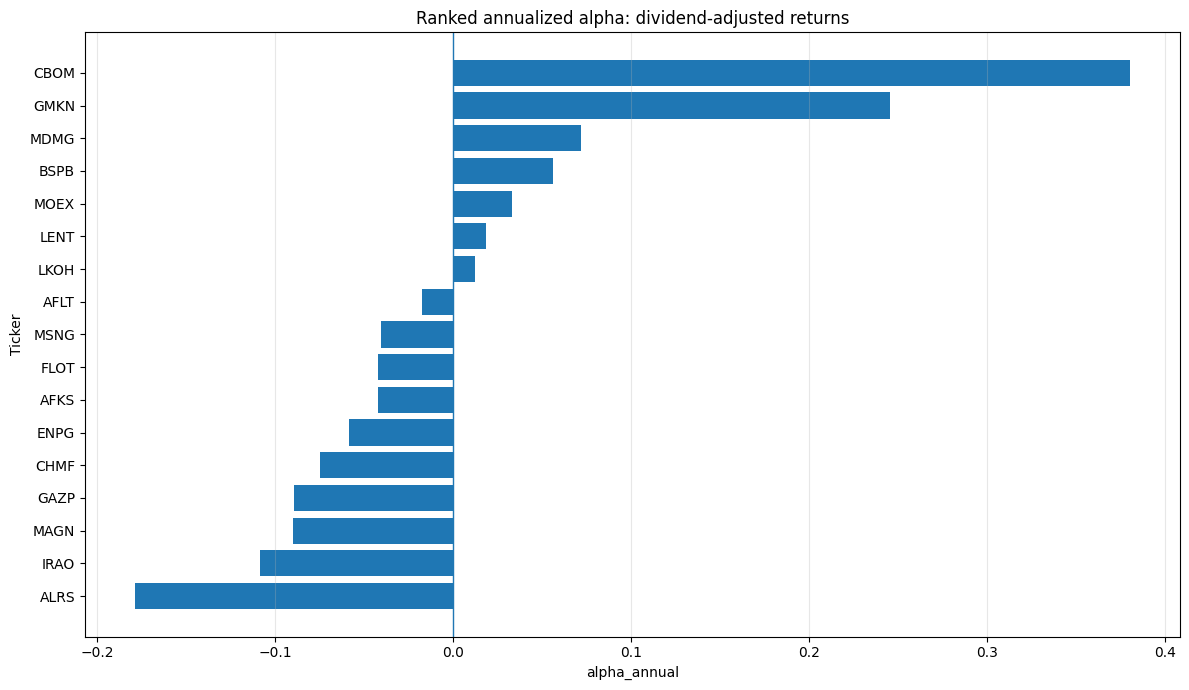

In [16]:
# ============================================================
# 16. Ranked annual alpha
# ============================================================

plot_ranked_exposure(ff_total, "alpha_annual", "Ranked annualized alpha: dividend-adjusted returns")

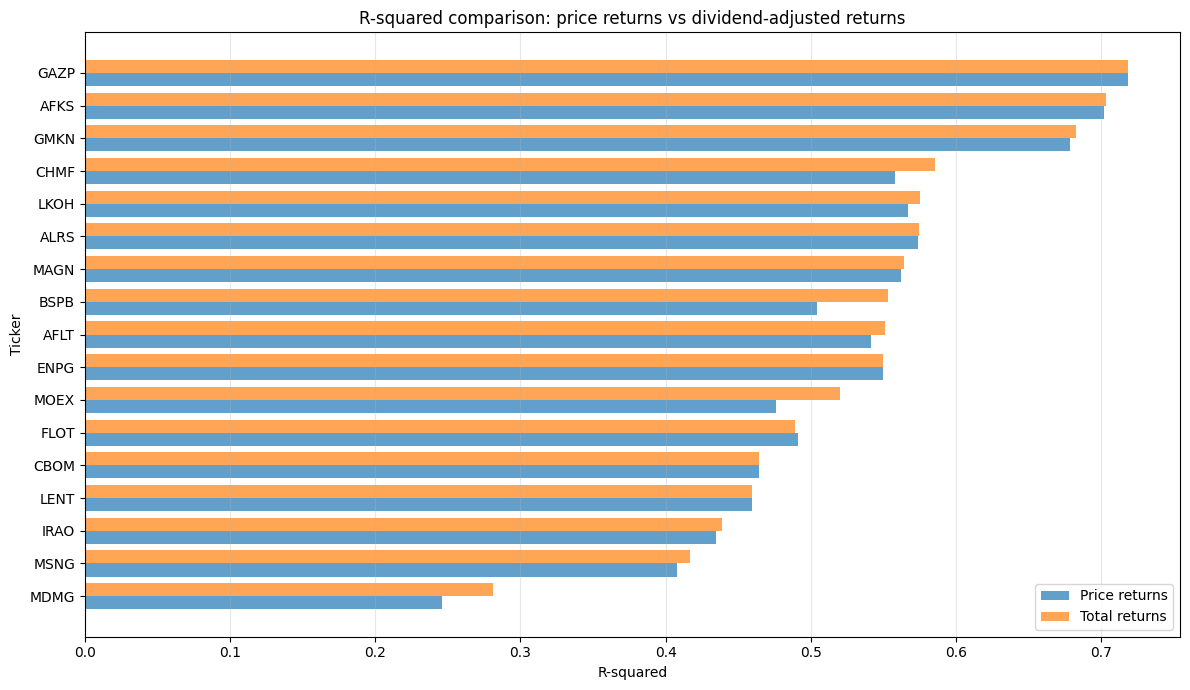

,R2_price,R2_total
ticker,,
MDMG,0.2459,0.2812
MSNG,0.4075,0.4164
IRAO,0.4349,0.4386
LENT,0.4596,0.4596
CBOM,0.4645,0.4645
FLOT,0.4913,0.4890
MOEX,0.4758,0.5197
ENPG,0.5497,0.5497
AFLT,0.5413,0.5510


In [19]:
# ============================================================
# 17. R-squared comparison: price vs total returns
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

r2_compare = pd.DataFrame({
    "R2_price": ff_price["R2"],
    "R2_total": ff_total["R2"]
}).dropna()

r2_compare = r2_compare.sort_values("R2_total")

# позиции по оси Y
y = np.arange(len(r2_compare))
height = 0.4

plt.figure(figsize=(12, 7))

# два столбца рядом
plt.barh(
    y - height/2,
    r2_compare["R2_price"],
    height=height,
    alpha=0.7,
    label="Price returns"
)

plt.barh(
    y + height/2,
    r2_compare["R2_total"],
    height=height,
    alpha=0.7,
    label="Total returns"
)

plt.yticks(y, r2_compare.index)

plt.title("R-squared comparison: price returns vs dividend-adjusted returns")
plt.xlabel("R-squared")
plt.ylabel("Ticker")

plt.legend()
plt.grid(True, axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

display(r2_compare.round(4))

## 10. Interpretation guide

### Market beta

- \( eta_{MKT} > 1 \): the stock is more sensitive to market movements than the market portfolio.
- \( eta_{MKT} < 1 \): the stock is less sensitive to market movements.

### SMB coefficient

- Positive SMB coefficient: the stock behaves more like small-cap stocks.
- Negative SMB coefficient: the stock behaves more like large-cap stocks.

### HML coefficient

- Positive HML coefficient: the stock behaves more like value/high-dividend-yield stocks.
- Negative HML coefficient: the stock behaves more like growth/low-dividend-yield stocks.

### MOM coefficient

- Positive MOM coefficient: the stock has positive exposure to momentum winners.
- Negative MOM coefficient: the stock behaves more like past losers.

### Alpha

- Positive significant alpha: the stock delivered abnormal return unexplained by the factor model.
- Negative significant alpha: the stock underperformed relative to the factor model.

## 11. Export results to Excel

The final workbook includes:

- IMOEX constituents
- Clean return matrices
- Factor returns
- Factor classifications
- Regression results for price returns
- Regression results for dividend-adjusted total returns
- Formatted regression tables

In [18]:
# ============================================================
# 18. Export to Excel
# ============================================================

output_file = f"imoex_fama_french_after_2022_{AS_OF_DATE}.xlsx"

classification_export = classification.copy()
classification_export["size_group"] = size_group
classification_export["value_group"] = value_group
classification_export["momentum_score"] = mom_score
classification_export["momentum_group"] = mom_group

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    imoex_constituents_table.to_excel(writer, sheet_name="IMOEX_constituents", index=False)
    pd.DataFrame({"complete_tickers": complete_tickers}).to_excel(writer, sheet_name="Complete_tickers", index=False)

    R_price.to_excel(writer, sheet_name="Price_returns")
    R_total.to_excel(writer, sheet_name="Total_returns")
    factors.to_excel(writer, sheet_name="Factors")
    factor_summary.to_excel(writer, sheet_name="Factor_summary")

    classification_export.to_excel(writer, sheet_name="Factor_classification")

    ff_price.to_excel(writer, sheet_name="FF_price_results")
    ff_total.to_excel(writer, sheet_name="FF_total_results")

    ff_price_table.to_excel(writer, sheet_name="FF_price_table")
    ff_total_table.to_excel(writer, sheet_name="FF_total_table")

print("Saved:", output_file)

Saved: imoex_fama_french_after_2022_2026-04-24.xlsx
